<a href="https://colab.research.google.com/github/RaniaDK/Projet_ML/blob/main/projet_ml_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# **1.2 Charger le dataset**

In [ ]:
df = pd.read_excel("/content/cancer_patient_dirty_pro.xlsx")

df = df.dropna(subset=['Level'])
df.head()

,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,NaN,33.0,1.0,2.000000,4.0,15.058866,4.0,3.0,2.0,2.000000,...,NaN,4.000000,2.0,2.0,3.0,1.0,NaN,3.0,4.0,Low
1,NaN,17.0,NaN,3.000000,1.0,5.000000,3.0,4.0,2.0,2.000000,...,1.0,3.000000,7.0,NaN,6.0,2.0,1.0,NaN,2.0,Medium
2,P100,35.0,1.0,13.984879,5.0,6.000000,5.0,5.0,4.0,15.184317,...,8.0,7.000000,9.0,NaN,1.0,4.0,6.0,7.0,2.0,High
3,NaN,37.0,NaN,7.000000,NaN,NaN,7.0,6.0,7.0,7.000000,...,4.0,NaN,3.0,1.0,4.0,5.0,6.0,7.0,5.0,High
5,P102,35.0,1.0,4.000000,NaN,NaN,5.0,5.0,NaN,NaN,...,8.0,14.760163,9.0,2.0,1.0,4.0,NaN,7.0,2.0,High


# **1.3 Dimensions du dataset**

In [ ]:
df.shape

(885, 25)

# **1.4 Informations générales**

In [ ]:
print(df.isnull().sum())

Patient Id                  177
Age                         182
Gender                      167
Air Pollution               152
Alcohol use                 203
Dust Allergy                162
OccuPational Hazards        169
Genetic Risk                157
chronic Lung Disease        163
Balanced Diet               181
Obesity                     192
Smoking                     147
Passive Smoker              190
Chest Pain                  164
Coughing of Blood           164
Fatigue                     167
Weight Loss                 187
Shortness of Breath         199
Wheezing                    182
Swallowing Difficulty       169
Clubbing of Finger Nails    169
Frequent Cold               157
Dry Cough                   164
Snoring                     179
Level                         0
dtype: int64


# **1.5 Statistiques**

In [ ]:
df.describe()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring
count,703.000000,718.000000,733.000000,682.000000,723.000000,716.000000,728.000000,722.000000,704.000000,693.000000,...,721.000000,718.000000,698.000000,686.000000,703.000000,716.000000,716.000000,728.000000,721.000000,706.000000
mean,39.698502,1.588387,4.300779,5.221878,5.612808,5.313992,5.201994,4.927048,5.062093,5.068515,...,5.530148,4.594379,4.461900,4.873232,4.354347,4.249372,4.629305,4.157079,4.310062,3.461667
std,17.065025,0.791599,2.938837,3.984657,2.880063,3.011241,3.248064,2.812735,3.008905,3.298353,...,3.796548,3.558645,3.317344,3.356052,3.016330,3.236645,3.587908,2.844055,2.961979,2.315072
min,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,28.000000,1.000000,2.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,37.000000,1.000000,4.000000,5.000000,6.000000,5.000000,5.000000,5.000000,6.000000,4.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000
75%,46.000000,2.000000,6.000000,7.000000,7.000000,7.000000,7.000000,6.000000,7.000000,7.000000,...,7.000000,5.000000,7.000000,6.000000,6.000000,6.000000,5.000000,6.000000,6.000000,4.750000
max,97.282713,3.855036,13.984879,17.649259,15.058866,15.327819,15.286951,13.565776,15.184317,15.154303,...,16.754927,14.726239,14.760163,15.795202,14.058496,15.146780,15.664702,12.590705,14.015851,10.324708


# **1.6 Vérifier la target**

In [ ]:
df["Level"].value_counts()

,count
Level,
High,326
Medium,286
Low,273


# **ÉTAPE 2 : Analyse Exploratoire des Données (EDA)**

# **2.1 Distribution de la target**

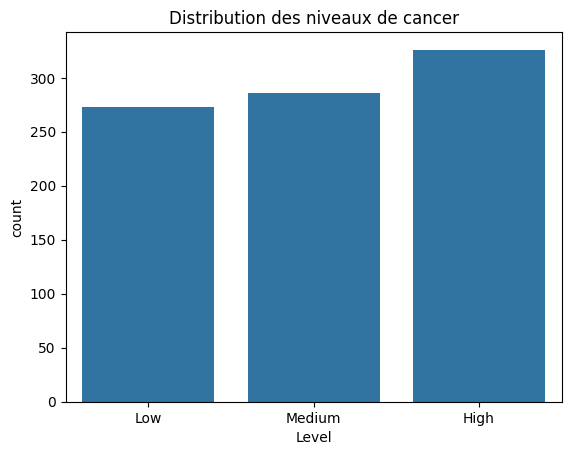

In [ ]:
sns.countplot(x="Level", data=df)
plt.title("Distribution des niveaux de cancer")
plt.show()

# **2.2 Histogrammes**

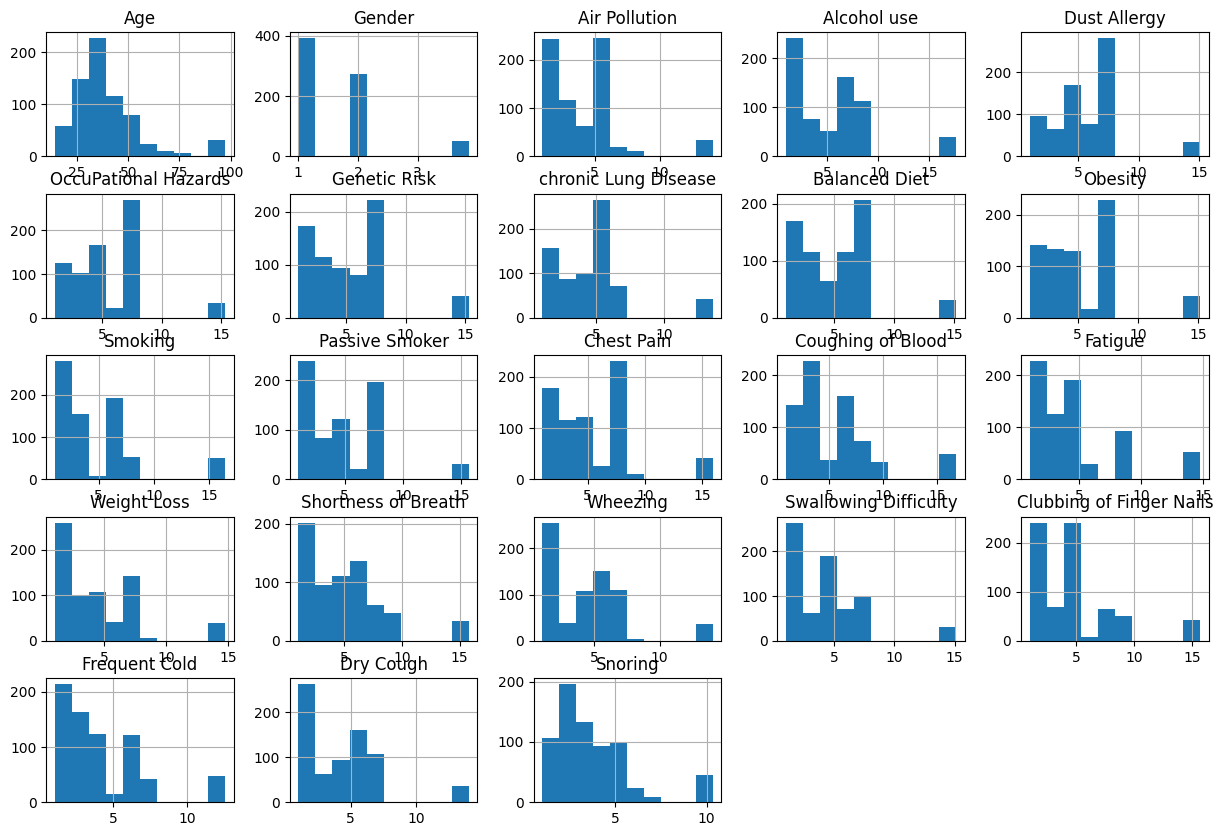

In [ ]:
df.hist(figsize=(15,10))
plt.show()

# **2.3 Corrélation entre variables**

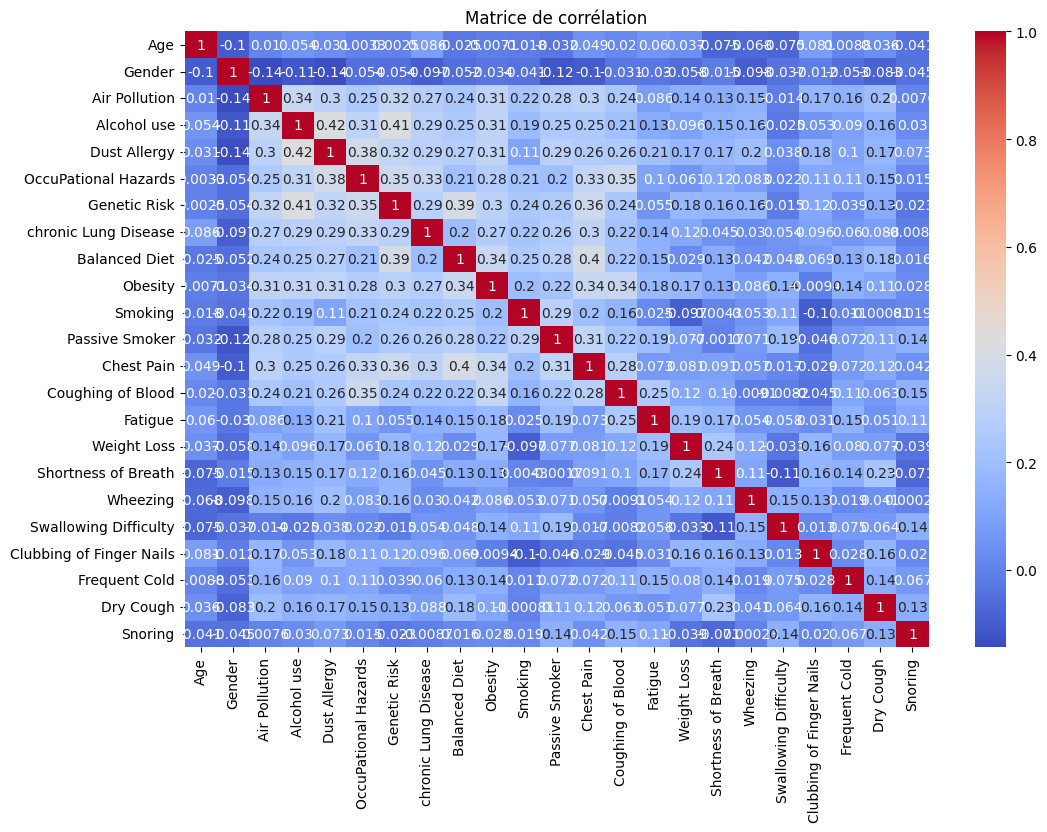

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

# **2.4 Boxplot **

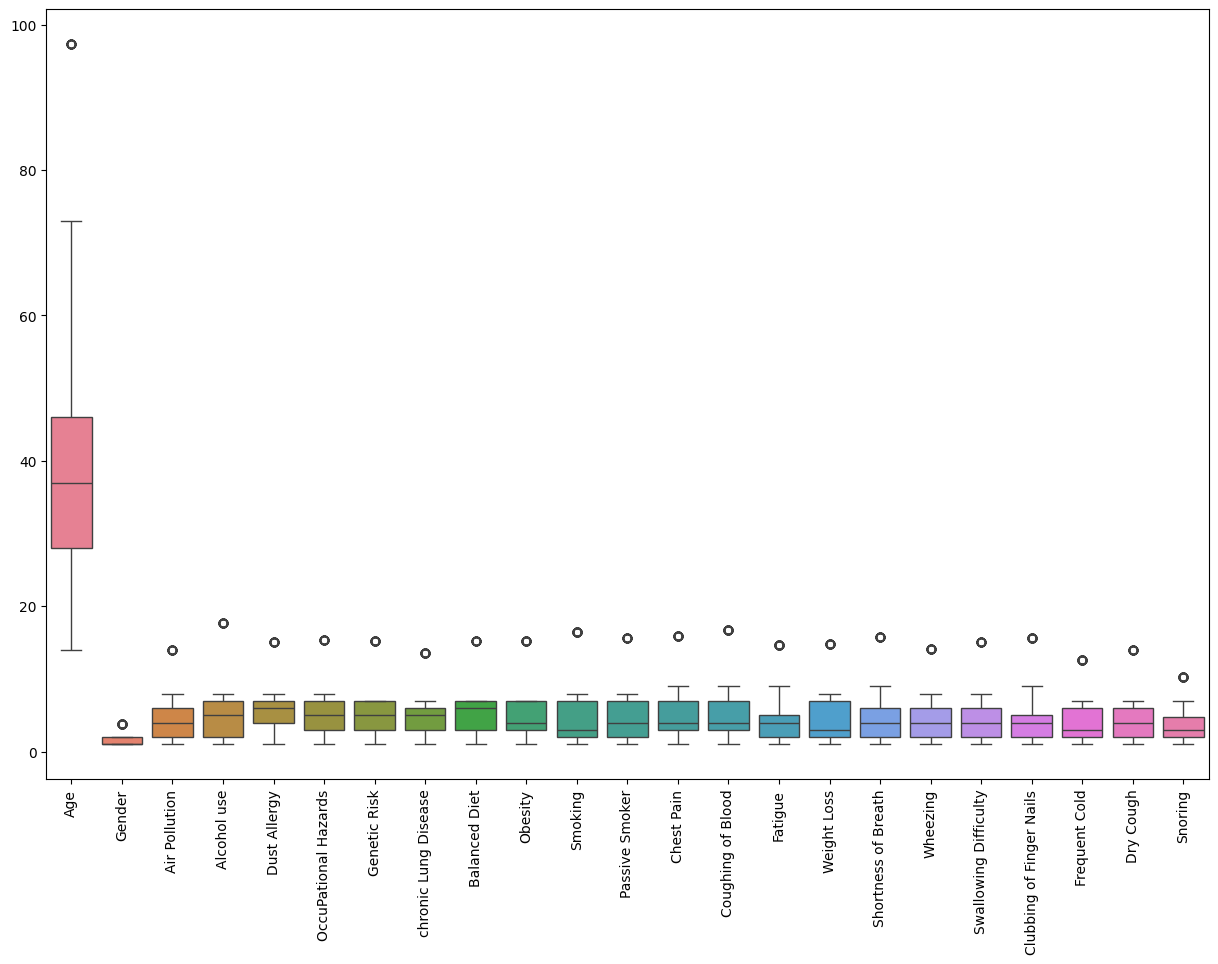

In [ ]:
plt.figure(figsize=(15,10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# **ÉTAPE 3 :**

# **1- Traitement des Valeurs Manquantes**

In [ ]:
df = df.fillna(df.median(numeric_only=True))

le = LabelEncoder()
df['Level'] = le.fit_transform(df['Level'].astype(str))

print(df.isnull().sum())

Patient Id                  177
Age                           0
Gender                        0
Air Pollution                 0
Alcohol use                   0
Dust Allergy                  0
OccuPational Hazards          0
Genetic Risk                  0
chronic Lung Disease          0
Balanced Diet                 0
Obesity                       0
Smoking                       0
Passive Smoker                0
Chest Pain                    0
Coughing of Blood             0
Fatigue                       0
Weight Loss                   0
Shortness of Breath           0
Wheezing                      0
Swallowing Difficulty         0
Clubbing of Finger Nails      0
Frequent Cold                 0
Dry Cough                     0
Snoring                       0
Level                         0
dtype: int64


# **2- Suppression des Colonnes Inutiles**

In [ ]:
if 'Patient Id' in df.columns:
    df = df.drop('Patient Id', axis=1)

print(df.columns)

Index(['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy',
       'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease',
       'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain',
       'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath',
       'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails',
       'Frequent Cold', 'Dry Cough', 'Snoring', 'Level'],
      dtype='object')


# **3- Correction des Outliers**

In [ ]:
# Ay ra9m akthar mel 8 (kima 15.18), nradouh 8 bedhabt
cols_to_fix = ['Air Pollution', 'Alcohol use', 'Dust Allergy', 'Balanced Diet']

for col in cols_to_fix:
    df[col] = df[col].clip(upper=8)

# N3awdou describe bech nchoufou el Max rja3 8 walla lé
print(df[cols_to_fix].describe().loc['max'])

Air Pollution    8.0
Alcohol use      8.0
Dust Allergy     8.0
Balanced Diet    8.0
Name: max, dtype: float64


# **4- Vérification Finale**

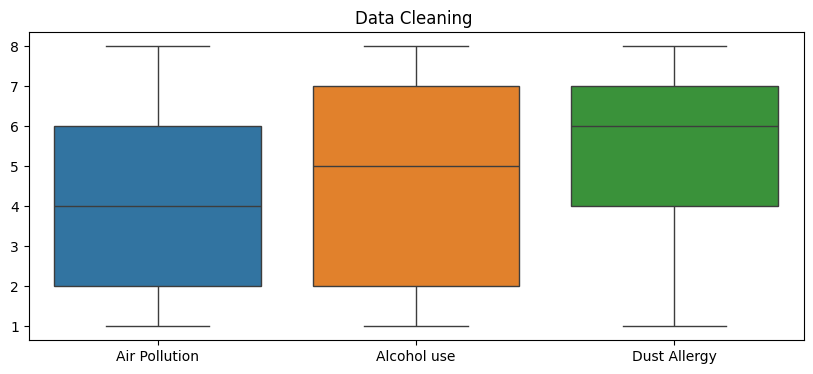

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df[['Air Pollution', 'Alcohol use', 'Dust Allergy']])
plt.title("Data Cleaning ")
plt.show()

# **Étape 5: Analyse de Corrélation**

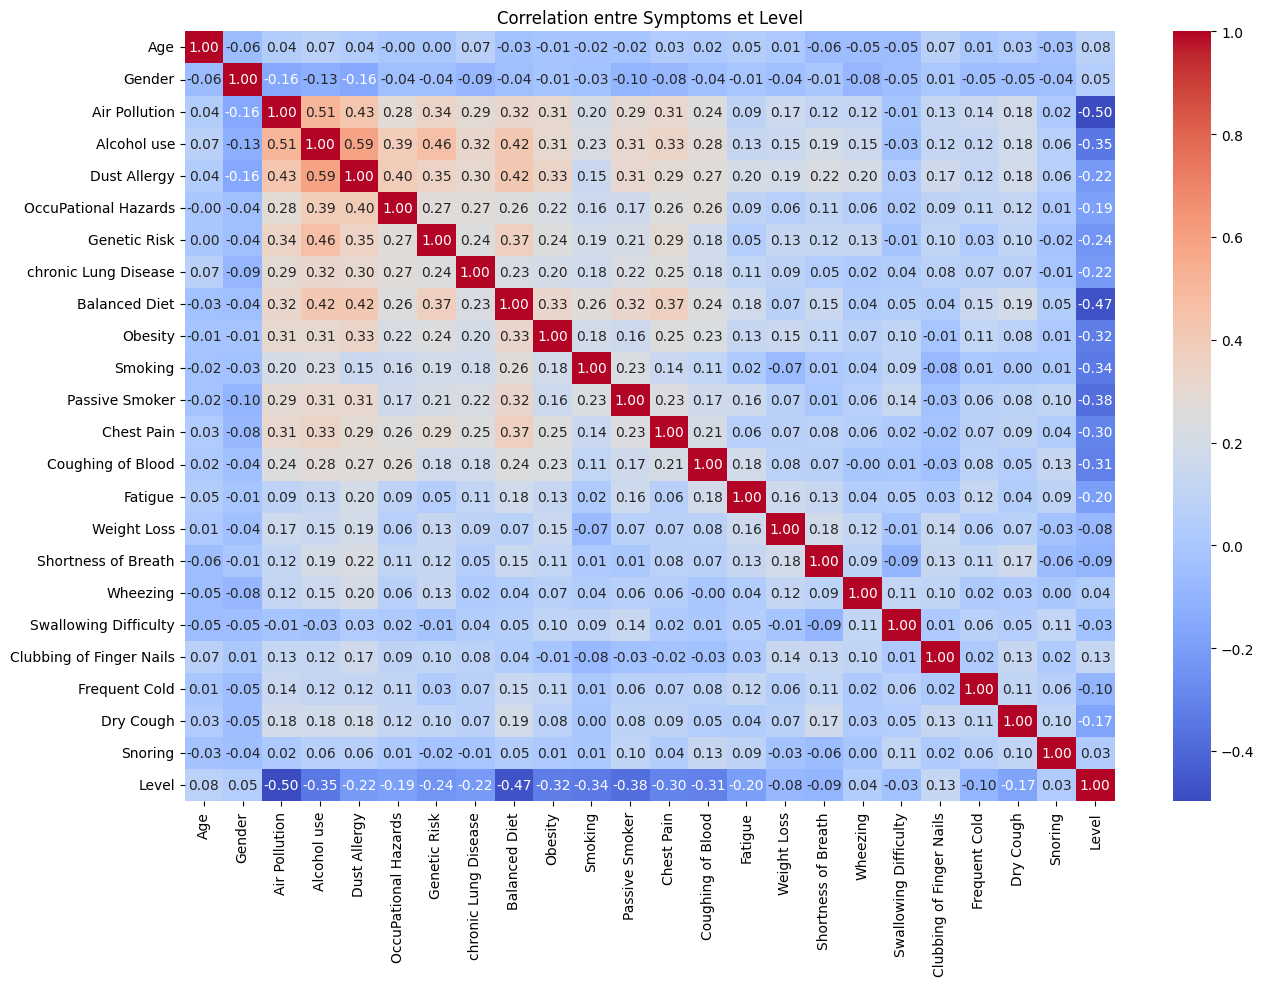

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation entre Symptoms et Level")
plt.show()

# **Étape 6: Préparation des Données**

In [ ]:
X = df.drop('Level', axis=1)
y = df['Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data Training: {X_train.shape[0]} patients")
print(f"Data Testing: {X_test.shape[0]} patients")

Data Training: 708 patients
Data Testing: 177 patients


# **Modèle 1: SVM (Support Vector Machine)**

In [ ]:
svm_model = SVC(kernel='linear', random_state=42)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm)*100:.2f}%")

SVM Accuracy: 82.49%


# **Modèle 2: KNN (K-Nearest Neighbors)**

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn)*100:.2f}%")

KNN Accuracy: 82.49%


# **Modèle 3: Logistic Regression (Régression Logistique)**

Logistic Regression Accuracy: 84.75%


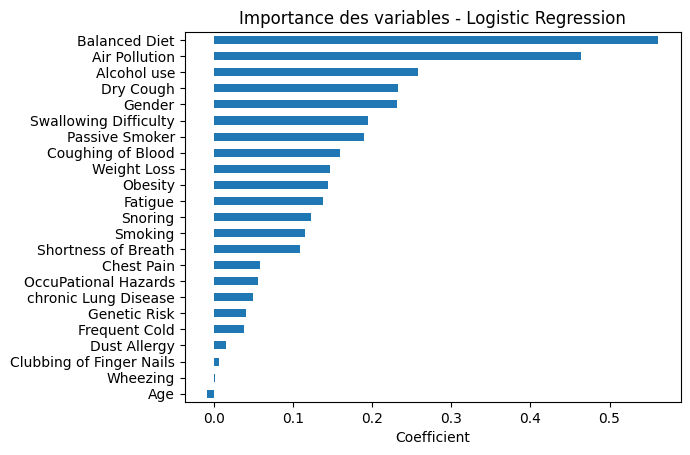

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")

coefficients = pd.Series(lr_model.coef_[0], index=X.columns)

coefficients.sort_values().plot(kind='barh')
plt.title("Importance des variables - Logistic Regression")
plt.xlabel("Coefficient")
plt.show()

# **Modèle 4: Decision Tree (Arbre de Décision)**

Decision Tree Accuracy: 91.53%


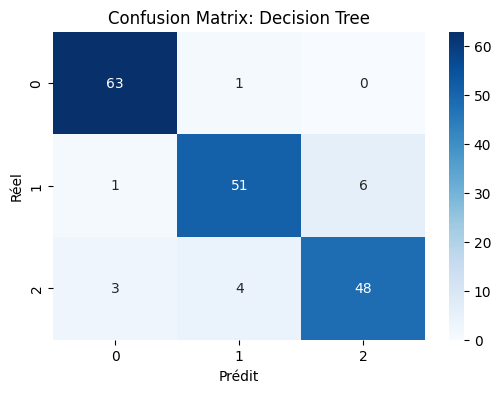

In [ ]:
# 1. Khla9na el "Mokh" mte3 el Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# 2. El AI yabda yet3allem (Fit)
dt_model.fit(X_train, y_train)

# 3. El AI ijarreb yetwa9a3 el Data mte3 el Test
y_pred_dt = dt_model.predict(X_test)

# 4. Affichage mte3 el Accuracy
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt)*100:.2f}%")

# 5. Confusion Matrix bch nchoufou el ghaltat
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# **Modèle 5: Random Forest (Forêt Aléatoire)**

Random Forest Accuracy: 98.31%


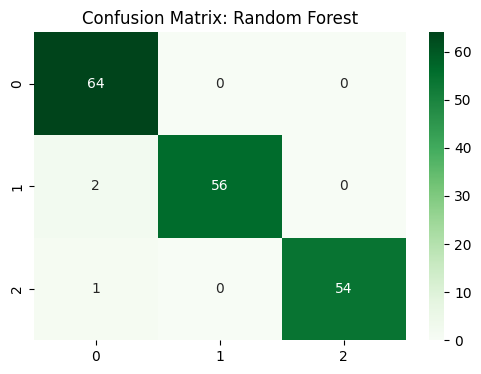

In [ ]:
# 1. Création du modèle avec 100 arbres
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Random Forest')
plt.show()

# **Feature Importance**

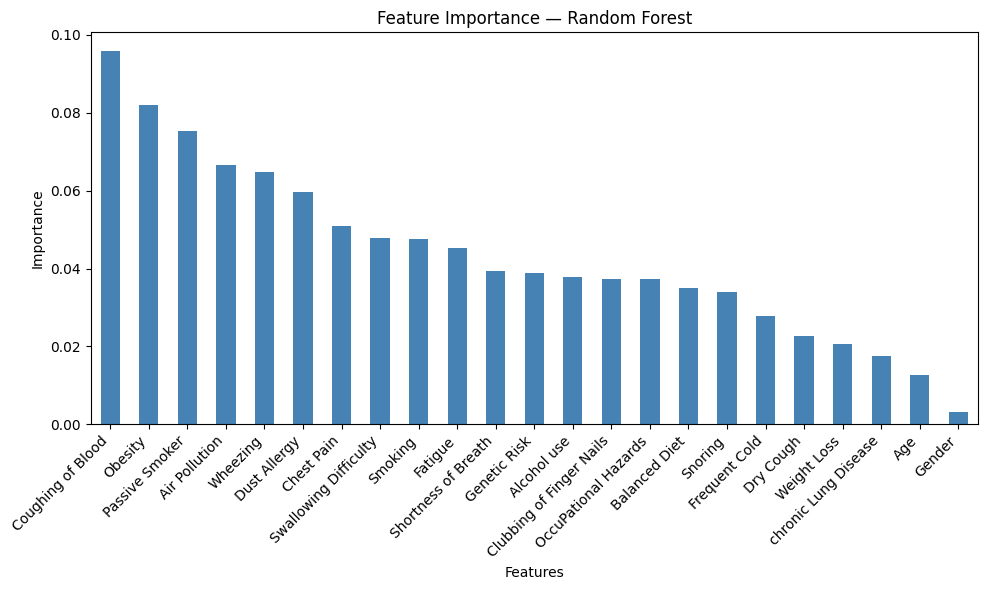

Top 10 Features les plus importantes :
Coughing of Blood        0.095876
Obesity                  0.081990
Passive Smoker           0.075313
Air Pollution            0.066484
Wheezing                 0.064794
Dust Allergy             0.059702
Chest Pain               0.050874
Swallowing Difficulty    0.047933
Smoking                  0.047491
Fatigue                  0.045229
dtype: float64


In [ ]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)


plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue')
plt.title("Feature Importance — Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 Features les plus importantes :")
print(importances.head(10))

# **Interprétation & Conclusion **

             Modèle  Accuracy
      Random Forest  0.983051
      Decision Tree  0.915254
Logistic Regression  0.847458
                SVM  0.824859
                KNN  0.824859


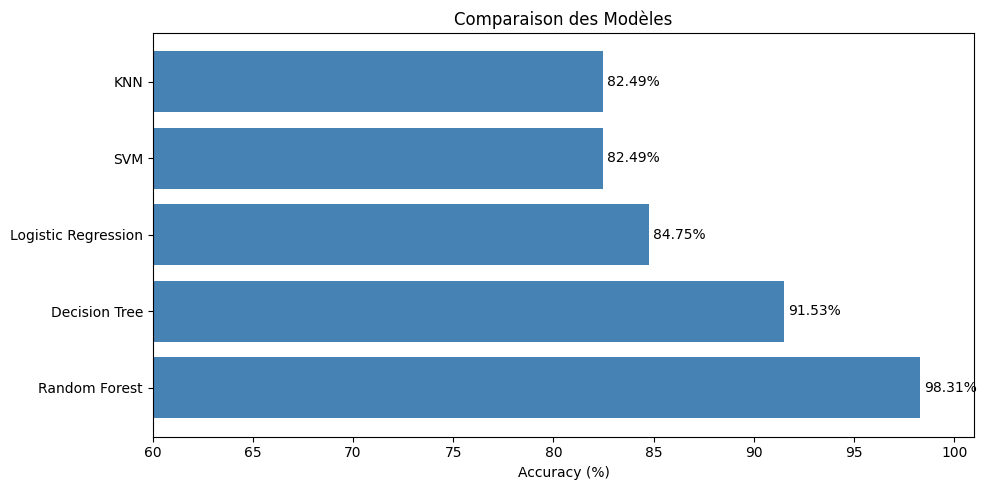

In [ ]:
results = {
    'Decision Tree':        accuracy_score(y_test, y_pred_dt),
    'Random Forest':        accuracy_score(y_test, y_pred_rf),
    'SVM':                  accuracy_score(y_test, y_pred_svm),
    'KNN':                  accuracy_score(y_test, y_pred_knn),
    'Logistic Regression':  accuracy_score(y_test, y_pred_lr),
}

results_df = pd.DataFrame(
    list(results.items()),
    columns=['Modèle', 'Accuracy']
).sort_values('Accuracy', ascending=False)

print(results_df.to_string(index=False))


plt.figure(figsize=(10, 5))
plt.barh(results_df['Modèle'], results_df['Accuracy']*100, color='steelblue')
plt.xlabel('Accuracy (%)')
plt.title('Comparaison des Modèles')
plt.xlim(60, 101)
for i, v in enumerate(results_df['Accuracy']*100):
    plt.text(v + 0.2, i, f'{v:.2f}%', va='center')
plt.tight_layout()
plt.show()


In [ ]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print(" Fichiers sauvegardés !")

from google.colab import files
files.download('model.pkl')
files.download('label_encoder.pkl')

NameError: name 'rf_model' is not defined